In [1]:
pip install scipy

Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simple
Note: you may need to restart the kernel to use updated packages.


Starting implicit FDM solver (Logistic + Apparent Heat Capacity)...
Diagnostics:
  T range       : [-11.926392, 1.000000]
  theta range   : [0.171456, 0.259736]
  dtheta/dT     : [0.005444, 0.007500]
  C_eff range   : [2.058813, 2.280219]
  C_app range   : [3.876987, 4.774665]
  lambda range  : [0.140898, 0.154207]
  dx = 0.050000, dt = 0.024335
  Progress: 10.0%   elapsed: 0.8s
  Progress: 20.0%   elapsed: 1.6s
  Progress: 30.0%   elapsed: 2.3s
  Progress: 40.0%   elapsed: 3.1s
  Progress: 50.0%   elapsed: 3.9s
  Progress: 60.0%   elapsed: 4.7s
  Progress: 70.0%   elapsed: 5.4s
  Progress: 80.0%   elapsed: 6.2s
  Progress: 90.0%   elapsed: 7.1s
Solution completed in 9.6s
Diagnostics:
  T range       : [-11.926392, 2.393861]
  theta range   : [0.171456, 0.270083]
  dtheta/dT     : [0.005444, 0.007500]
  C_eff range   : [2.058813, 2.306167]
  C_app range   : [3.876987, 4.774924]
  lambda range  : [0.139338, 0.154207]
  dx = 0.050000, dt = 0.024335
Results saved to fdm_logistic_ahc_3year

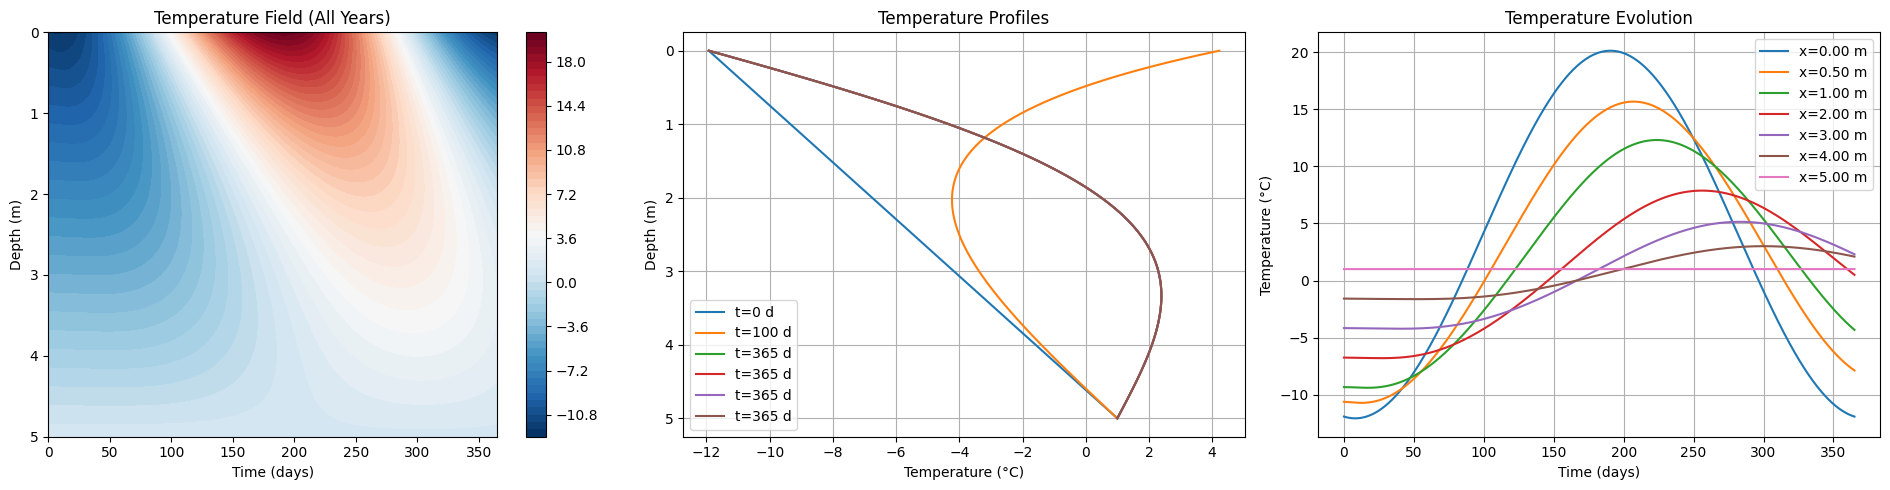

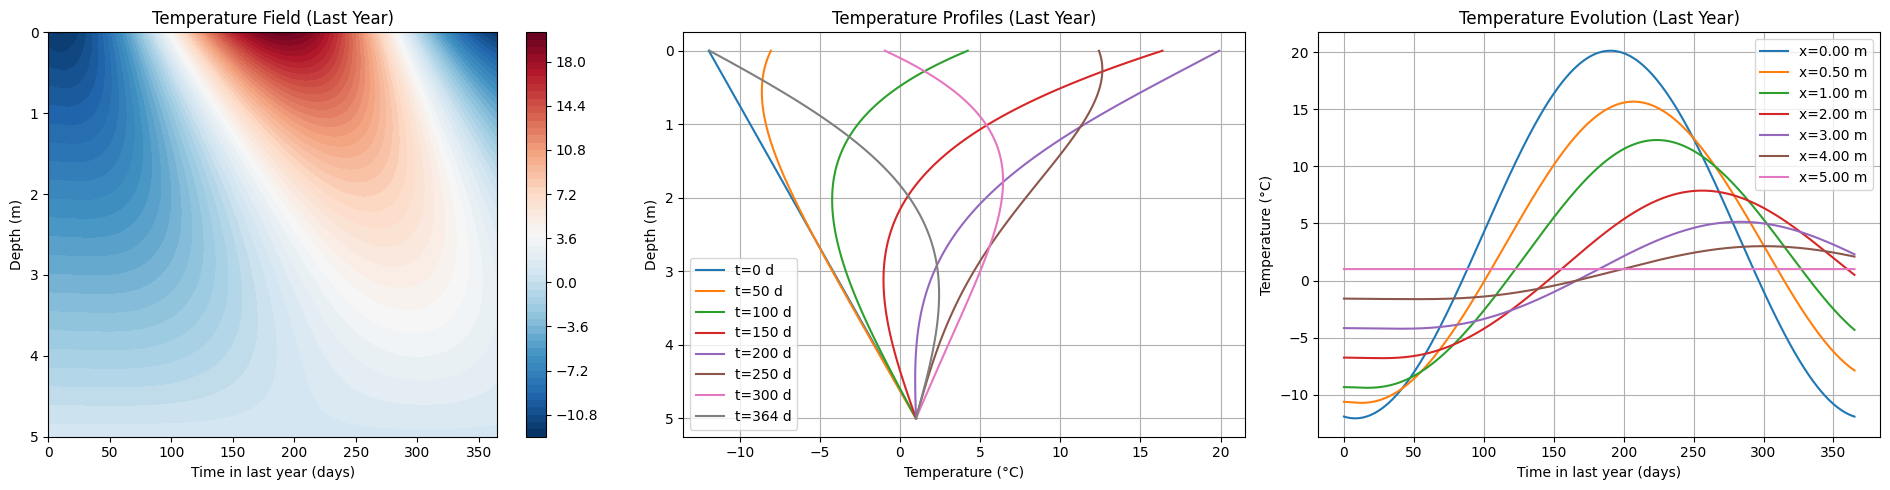

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import time


class FreezingSoilFDM_LogisticAHC:
    """
    1D freezing/thawing soil model
    Logistic unfrozen water content + apparent heat capacity (AHC) method
    """

    def __init__(self, params):
        # ---------------------------
        # Physical parameters
        # ---------------------------
        self.L = params['L']                      # latent heat [MJ/m^3]
        self.C_i = params['C_i']                  # ice volumetric heat capacity
        self.C_l = params['C_l']                  # liquid water volumetric heat capacity
        self.C_f = params['C_f']                  # soil skeleton volumetric heat capacity

        self.lambda_i = params['lambda_i']        # ice thermal conductivity [MJ/(day·m·K)]
        self.lambda_l = params['lambda_l']        # liquid water thermal conductivity
        self.lambda_f = params['lambda_f']        # soil skeleton thermal conductivity

        self.eta = params['eta']                  # porosity / max unfrozen water content upper bound
        self.theta_r = params['theta_r']          # residual unfrozen water content
        self.T_f = params['T_f']                  # freezing transition center temperature
        self.k = params['k']                      # logistic steepness

        # ---------------------------
        # Grid parameters
        # ---------------------------
        self.Nx = None
        self.Nt = None
        self.Lx = None
        self.T_total = None
        self.dx = None
        self.dt = None

        self.x = None
        self.t = None
        self.T_field = None

    # =========================================================
    # Boundary / initial conditions
    # =========================================================
    def boundary_temperature(self, t):
        """
        Surface temperature boundary condition [degC]
        You can modify this function directly if needed.
        """
        return 4.03 + 16.11 * np.sin(2.0 * np.pi * t / 365.0 - 1.709)

    def initial_temperature_profile(self, x):
        """
        Initial temperature profile [degC]
        Linear profile from surface initial temperature to bottom temperature.
        """
        T_surface = self.boundary_temperature(0.0)
        T_bottom = 1.0
        return T_surface + (T_bottom - T_surface) * x / self.Lx

    # =========================================================
    # Logistic unfrozen water model
    # =========================================================
    def theta_unfrozen(self, T):
        """
        Logistic unfrozen water content:
            theta(T) = theta_r + (eta - theta_r)/(1 + exp(-k*(T - T_f)))
        """
        z = np.clip(-self.k * (np.asarray(T) - self.T_f), -60.0, 60.0)
        return self.theta_r + (self.eta - self.theta_r) / (1.0 + np.exp(z))

    def dtheta_dT(self, T):
        """
        Derivative of logistic unfrozen water content:
            dtheta/dT = (eta - theta_r) * k * exp(-k*(T-T_f)) / (1+exp(-k*(T-T_f)))^2
        """
        z = np.clip(-self.k * (np.asarray(T) - self.T_f), -60.0, 60.0)
        ez = np.exp(z)
        return (self.eta - self.theta_r) * self.k * ez / (1.0 + ez) ** 2

    # =========================================================
    # Effective properties
    # =========================================================
    def effective_heat_capacity(self, T):
        """
        Sensible heat capacity only:
            C_eff = (1-eta) C_f + theta C_l + (eta-theta) C_i
        """
        theta = self.theta_unfrozen(T)
        return (1.0 - self.eta) * self.C_f + theta * self.C_l + (self.eta - theta) * self.C_i

    def apparent_heat_capacity(self, T):
        """
        Apparent heat capacity:
            C_app = C_eff + L * dtheta/dT
        """
        return self.effective_heat_capacity(T) + self.L * self.dtheta_dT(T)

    def effective_conductivity(self, T):
        """
        Effective conductivity:
            lambda_eff = (1-eta) lambda_f + theta lambda_l + (eta-theta) lambda_i
        """
        theta = self.theta_unfrozen(T)
        return (1.0 - self.eta) * self.lambda_f + theta * self.lambda_l + (self.eta - theta) * self.lambda_i

    @staticmethod
    def harmonic_mean(a, b, eps=1e-12):
        return 2.0 * a * b / (a + b + eps)

    # =========================================================
    # Initialization
    # =========================================================
    def initialize(self, Nx=101, Nt=15000, Lx=5.0, T_total=365.0 * 3):
        self.Nx = Nx
        self.Nt = Nt
        self.Lx = Lx
        self.T_total = T_total

        self.dx = Lx / (Nx - 1)
        self.dt = T_total / (Nt - 1)

        self.x = np.linspace(0.0, Lx, Nx)
        self.t = np.linspace(0.0, T_total, Nt)

        self.T_field = np.zeros((Nx, Nt), dtype=float)
        self.T_field[:, 0] = self.initial_temperature_profile(self.x)

    # =========================================================
    # Diagnostics
    # =========================================================
    def print_diagnostics(self, T):
        theta = self.theta_unfrozen(T)
        dth = self.dtheta_dT(T)
        Ceff = self.effective_heat_capacity(T)
        Capp = self.apparent_heat_capacity(T)
        lam = self.effective_conductivity(T)

        print("Diagnostics:")
        print(f"  T range       : [{np.min(T):.6f}, {np.max(T):.6f}]")
        print(f"  theta range   : [{np.min(theta):.6f}, {np.max(theta):.6f}]")
        print(f"  dtheta/dT     : [{np.min(dth):.6f}, {np.max(dth):.6f}]")
        print(f"  C_eff range   : [{np.min(Ceff):.6f}, {np.max(Ceff):.6f}]")
        print(f"  C_app range   : [{np.min(Capp):.6f}, {np.max(Capp):.6f}]")
        print(f"  lambda range  : [{np.min(lam):.6f}, {np.max(lam):.6f}]")
        print(f"  dx = {self.dx:.6f}, dt = {self.dt:.6f}")

    # =========================================================
    # Implicit solver
    # =========================================================
    def solve_implicit(self, verbose=True):
        """
        Solve:
            C_app(T) * dT/dt = d/dx( lambda(T) dT/dx )

        Backward-Euler-like implicit discretization with coefficients evaluated at old time step.
        """
        if self.T_field is None:
            raise RuntimeError("Please call initialize() first.")

        start = time.time()
        T_old = self.T_field[:, 0].copy()

        if verbose:
            print("Starting implicit FDM solver (Logistic + Apparent Heat Capacity)...")
            self.print_diagnostics(T_old)

        for n in range(1, self.Nt):
            t_new = self.t[n]

            C_app = self.apparent_heat_capacity(T_old)
            lam = self.effective_conductivity(T_old)

            A = np.zeros((self.Nx, self.Nx), dtype=float)
            b = np.zeros(self.Nx, dtype=float)

            # ---------------------------
            # Top boundary: Dirichlet
            # ---------------------------
            A[0, 0] = 1.0
            b[0] = self.boundary_temperature(t_new)

            # ---------------------------
            # Bottom boundary: Dirichlet
            # ---------------------------
            A[-1, -1] = 1.0
            b[-1] = 1.0

            # ---------------------------
            # Interior nodes
            # ---------------------------
            for i in range(1, self.Nx - 1):
                lam_p = self.harmonic_mean(lam[i], lam[i + 1])
                lam_m = self.harmonic_mean(lam[i], lam[i - 1])

                coef = self.dt / (C_app[i] * self.dx ** 2)

                A[i, i - 1] = -coef * lam_m
                A[i, i] = 1.0 + coef * (lam_p + lam_m)
                A[i, i + 1] = -coef * lam_p

                b[i] = T_old[i]

            T_new = np.linalg.solve(A, b)

            if np.any(np.isnan(T_new)) or np.any(np.isinf(T_new)):
                raise RuntimeError(f"NaN/Inf detected at time step {n}")

            self.T_field[:, n] = T_new
            T_old = T_new.copy()

            if verbose and n % max(1, self.Nt // 10) == 0:
                print(f"  Progress: {100.0 * n / self.Nt:.1f}%   elapsed: {time.time() - start:.1f}s")

        if verbose:
            print(f"Solution completed in {time.time() - start:.1f}s")
            self.print_diagnostics(T_old)

        return self.T_field

    # =========================================================
    # Post-processing
    # =========================================================
    def get_last_year_data(self):
        if self.T_field is None:
            raise RuntimeError("No results available.")
        t_start = self.T_total - 365.0
        mask = self.t >= t_start
        return self.t[mask] - t_start, self.T_field[:, mask]

    def save_results(self, filename="fdm_logistic_ahc_3years.npz"):
        np.savez(
            filename,
            x=self.x,
            t=self.t,
            T_field=self.T_field,
            params={
                'L': self.L,
                'C_i': self.C_i,
                'C_l': self.C_l,
                'C_f': self.C_f,
                'lambda_i': self.lambda_i,
                'lambda_l': self.lambda_l,
                'lambda_f': self.lambda_f,
                'eta': self.eta,
                'theta_r': self.theta_r,
                'T_f': self.T_f,
                'k': self.k
            }
        )
        print(f"Results saved to {filename}")

    def save_last_year_results(self, filename="fdm_logistic_ahc_last_year.npz"):
        t_last, T_last = self.get_last_year_data()
        np.savez(
            filename,
            x=self.x,
            t=t_last,
            T_field=T_last
        )
        print(f"Last-year results saved to {filename}")

    # =========================================================
    # Plotting
    # =========================================================
    def plot_results(self):
        fig, axes = plt.subplots(1, 3, figsize=(19, 5))

        im = axes[0].contourf(self.t, self.x, self.T_field, levels=60, cmap='RdBu_r')
        axes[0].invert_yaxis()
        axes[0].set_xlabel('Time (days)')
        axes[0].set_ylabel('Depth (m)')
        axes[0].set_title('Temperature Field (All Years)')
        plt.colorbar(im, ax=axes[0])

        times_to_plot = [0, 100, 365, 730, 900, 1094]
        for tt in times_to_plot:
            idx = np.argmin(np.abs(self.t - tt))
            axes[1].plot(self.T_field[:, idx], self.x, label=f't={self.t[idx]:.0f} d')
        axes[1].invert_yaxis()
        axes[1].set_xlabel('Temperature (°C)')
        axes[1].set_ylabel('Depth (m)')
        axes[1].set_title('Temperature Profiles')
        axes[1].legend()
        axes[1].grid(True)

        depths_to_plot = [0, 0.5, 1, 2, 3, 4, 5]
        for dd in depths_to_plot:
            idx = np.argmin(np.abs(self.x - dd))
            axes[2].plot(self.t, self.T_field[idx, :], label=f'x={self.x[idx]:.2f} m')
        axes[2].set_xlabel('Time (days)')
        axes[2].set_ylabel('Temperature (°C)')
        axes[2].set_title('Temperature Evolution')
        axes[2].legend()
        axes[2].grid(True)

        plt.tight_layout()
        plt.show()

    def plot_last_year_results(self):
        t_last, T_last = self.get_last_year_data()

        fig, axes = plt.subplots(1, 3, figsize=(19, 5))

        im = axes[0].contourf(t_last, self.x, T_last, levels=60, cmap='RdBu_r')
        axes[0].invert_yaxis()
        axes[0].set_xlabel('Time in last year (days)')
        axes[0].set_ylabel('Depth (m)')
        axes[0].set_title('Temperature Field (Last Year)')
        plt.colorbar(im, ax=axes[0])

        times_to_plot = [0, 50, 100, 150, 200, 250, 300, 364]
        for tt in times_to_plot:
            idx = np.argmin(np.abs(t_last - tt))
            axes[1].plot(T_last[:, idx], self.x, label=f't={t_last[idx]:.0f} d')
        axes[1].invert_yaxis()
        axes[1].set_xlabel('Temperature (°C)')
        axes[1].set_ylabel('Depth (m)')
        axes[1].set_title('Temperature Profiles (Last Year)')
        axes[1].legend()
        axes[1].grid(True)

        depths_to_plot = [0, 0.5, 1, 2, 3, 4, 5]
        for dd in depths_to_plot:
            idx = np.argmin(np.abs(self.x - dd))
            axes[2].plot(t_last, T_last[idx, :], label=f'x={self.x[idx]:.2f} m')
        axes[2].set_xlabel('Time in last year (days)')
        axes[2].set_ylabel('Temperature (°C)')
        axes[2].set_title('Temperature Evolution (Last Year)')
        axes[2].legend()
        axes[2].grid(True)

        plt.tight_layout()
        plt.show()


if __name__ == "__main__":
    params = {
        # latent heat and volumetric heat capacities [MJ/m^3/K or MJ/m^3]
        'L': 334.0,
        'C_i': 1.672,
        'C_l': 4.18,
        'C_f': 1.60,

        # conductivities converted to MJ/(day·m·K)
        'lambda_i': 2.210e-6 * 8.64e4,
        'lambda_l': 0.465e-6 * 8.64e4,
        'lambda_f': 2.000e-6 * 8.64e4,

        # logistic unfrozen water parameters
        'eta': 0.40,        # upper limit
        'theta_r': 0.1,    # residual unfrozen water content
        'T_f': -0.3,        # transition center [degC]
        'k': 0.1            # transition steepness
    }

    model = FreezingSoilFDM_LogisticAHC(params)

    # 3-year simulation
    model.initialize(Nx=101, Nt=15000, Lx=5.0, T_total=365.0 * 1)

    T_field = model.solve_implicit(verbose=True)

    model.save_results("fdm_logistic_ahc_3years.npz")
    model.save_last_year_results("fdm_logistic_ahc_last_year.npz")

    print("All-years T min =", np.min(T_field))
    print("All-years T max =", np.max(T_field))
    print("Surface final T =", T_field[0, -1])
    print("Bottom final T =", T_field[-1, -1])

    # Plot all years
    model.plot_results()

    # Plot last year
    model.plot_last_year_results()

Training on device: cuda
Epoch      1 | Total 1.909221e+02 | PDE 1.304911e-05 | IC 4.560706e+01 | BC 1.453150e+02 | DATA 0.000000e+00 | elapsed 0.0s
Epoch    500 | Total 3.062845e-01 | PDE 1.603302e-01 | IC 1.603880e-02 | BC 1.299155e-01 | DATA 0.000000e+00 | elapsed 14.2s
Epoch   1000 | Total 7.480352e-02 | PDE 5.460455e-02 | IC 6.976128e-03 | BC 1.322284e-02 | DATA 0.000000e+00 | elapsed 27.8s
Epoch   1500 | Total 3.402218e-02 | PDE 2.673252e-02 | IC 1.936691e-03 | BC 5.352966e-03 | DATA 0.000000e+00 | elapsed 40.5s
Epoch   2000 | Total 3.155276e-02 | PDE 1.674090e-02 | IC 7.287180e-03 | BC 7.524674e-03 | DATA 0.000000e+00 | elapsed 53.2s
Epoch   2500 | Total 1.586427e-02 | PDE 1.232322e-02 | IC 1.314301e-03 | BC 2.226753e-03 | DATA 0.000000e+00 | elapsed 65.9s
Epoch   3000 | Total 1.121067e-02 | PDE 9.334778e-03 | IC 4.298748e-04 | BC 1.446016e-03 | DATA 0.000000e+00 | elapsed 78.5s
Epoch   3500 | Total 1.695493e-02 | PDE 7.770491e-03 | IC 4.180064e-03 | BC 5.004376e-03 | DATA 0.000

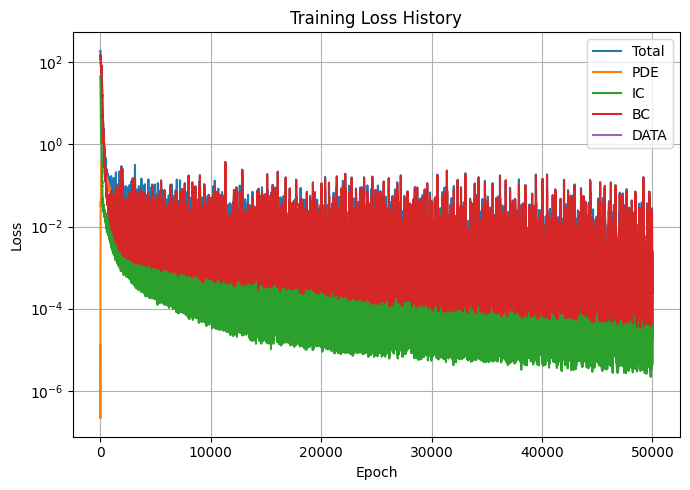

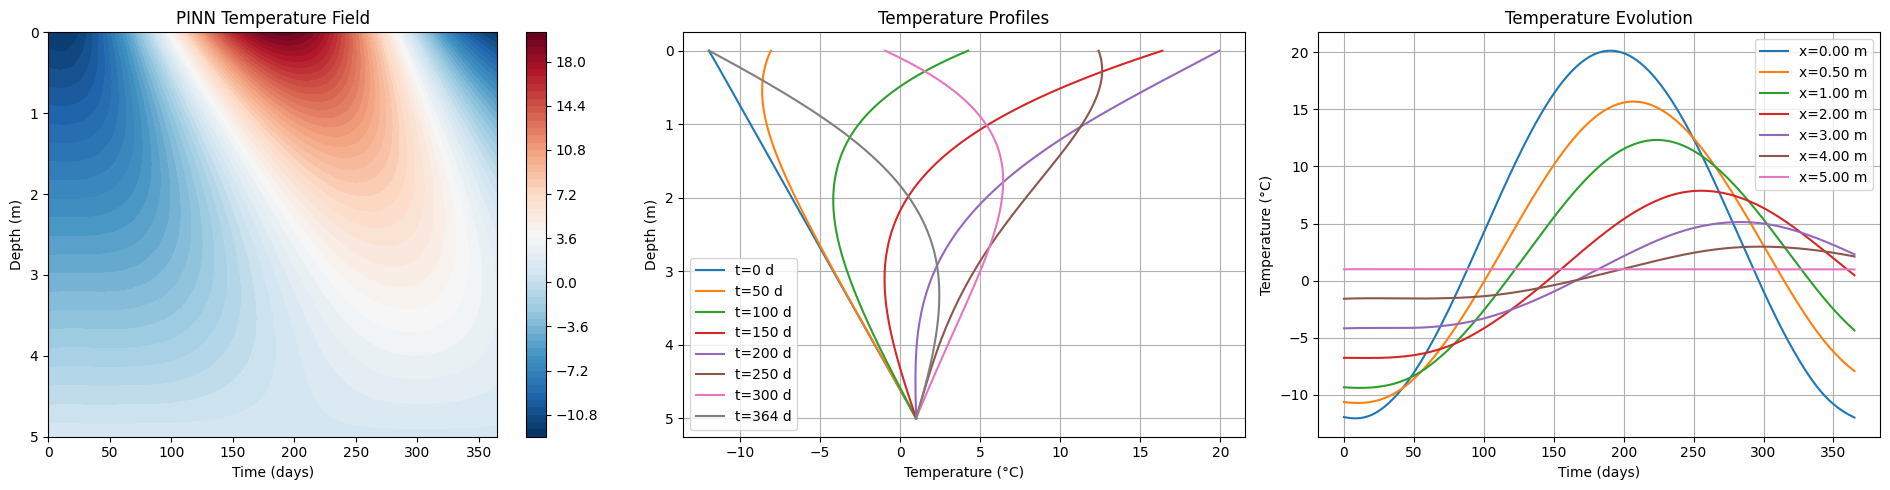

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import time


# =========================================================
# Neural network
# =========================================================
class MLP(nn.Module):
    def __init__(self, in_dim=2, out_dim=1, hidden_dim=64, num_hidden=5):
        super().__init__()
        layers = [nn.Linear(in_dim, hidden_dim), nn.Tanh()]
        for _ in range(num_hidden - 1):
            layers += [nn.Linear(hidden_dim, hidden_dim), nn.Tanh()]
        layers += [nn.Linear(hidden_dim, out_dim)]
        self.net = nn.Sequential(*layers)

        self._init_weights()

    def _init_weights(self):
        for m in self.net:
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        return self.net(x)


# =========================================================
# PINNs model for freezing/thawing soil
# =========================================================
class FreezingSoilPINN:
    """
    PINNs version corresponding to the uploaded FDM model:
        C_app(T) * dT/dt = d/dx( lambda(T) * dT/dx )

    Expanding the RHS:
        d/dx( lambda(T) * T_x )
        = lambda(T) * T_xx + d(lambda)/dT * (T_x)^2
    so the PDE residual becomes:
        C_app(T) * T_t - lambda(T) * T_xx - lambda_T(T) * (T_x)^2 = 0
    """

    def __init__(self, params, device=None):
        self.L = params['L']
        self.C_i = params['C_i']
        self.C_l = params['C_l']
        self.C_f = params['C_f']

        self.lambda_i = params['lambda_i']
        self.lambda_l = params['lambda_l']
        self.lambda_f = params['lambda_f']

        self.eta = params['eta']
        self.theta_r = params['theta_r']
        self.T_f = params['T_f']
        self.k = params['k']

        self.device = device if device is not None else (
            "cuda" if torch.cuda.is_available() else "cpu"
        )

        self.model = MLP(in_dim=2, out_dim=1, hidden_dim=64, num_hidden=5).to(self.device)

        # domain info
        self.Lx = None
        self.T_total = None

        # normalization scales
        self.x_scale = None
        self.t_scale = None

        # history
        self.loss_history = []

    # =========================================================
    # Boundary / initial conditions
    # =========================================================
    def boundary_temperature_np(self, t):
        return 4.03 + 16.11 * np.sin(2.0 * np.pi * t / 365.0 - 1.709)

    def boundary_temperature_torch(self, t):
        return 4.03 + 16.11 * torch.sin(2.0 * torch.pi * t / 365.0 - 1.709)

    def initial_temperature_profile_np(self, x):
        T_surface = self.boundary_temperature_np(0.0)
        T_bottom = 1.0
        return T_surface + (T_bottom - T_surface) * x / self.Lx

    def initial_temperature_profile_torch(self, x):
        T_surface = self.boundary_temperature_torch(torch.zeros_like(x))
        T_bottom = torch.ones_like(x) * 1.0
        return T_surface + (T_bottom - T_surface) * x / self.Lx

    # =========================================================
    # Logistic unfrozen water model
    # =========================================================
    def theta_unfrozen(self, T):
        z = torch.clamp(-self.k * (T - self.T_f), min=-60.0, max=60.0)
        return self.theta_r + (self.eta - self.theta_r) / (1.0 + torch.exp(z))

    def dtheta_dT(self, T):
        z = torch.clamp(-self.k * (T - self.T_f), min=-60.0, max=60.0)
        ez = torch.exp(z)
        return (self.eta - self.theta_r) * self.k * ez / (1.0 + ez) ** 2

    # =========================================================
    # Effective properties
    # =========================================================
    def effective_heat_capacity(self, T):
        theta = self.theta_unfrozen(T)
        return (1.0 - self.eta) * self.C_f + theta * self.C_l + (self.eta - theta) * self.C_i

    def apparent_heat_capacity(self, T):
        return self.effective_heat_capacity(T) + self.L * self.dtheta_dT(T)

    def effective_conductivity(self, T):
        theta = self.theta_unfrozen(T)
        return (1.0 - self.eta) * self.lambda_f + theta * self.lambda_l + (self.eta - theta) * self.lambda_i

    def dlambda_dT(self, T):
        """
        lambda(T) = (1-eta) lambda_f + theta lambda_l + (eta-theta) lambda_i
                  = const + theta (lambda_l - lambda_i)
        """
        return (self.lambda_l - self.lambda_i) * self.dtheta_dT(T)

    # =========================================================
    # PINN forward
    # =========================================================
    def net_T(self, x, t):
        """
        Network input uses normalized coordinates:
            x_hat = x / Lx
            t_hat = t / T_total
        """
        x_hat = x / self.x_scale
        t_hat = t / self.t_scale
        inp = torch.cat([x_hat, t_hat], dim=1)
        return self.model(inp)

    # =========================================================
    # PDE residual
    # =========================================================
    def pde_residual(self, x, t):
        x.requires_grad_(True)
        t.requires_grad_(True)

        T = self.net_T(x, t)

        T_t = torch.autograd.grad(
            T, t,
            grad_outputs=torch.ones_like(T),
            create_graph=True,
            retain_graph=True
        )[0]

        T_x = torch.autograd.grad(
            T, x,
            grad_outputs=torch.ones_like(T),
            create_graph=True,
            retain_graph=True
        )[0]

        T_xx = torch.autograd.grad(
            T_x, x,
            grad_outputs=torch.ones_like(T_x),
            create_graph=True,
            retain_graph=True
        )[0]

        C_app = self.apparent_heat_capacity(T)
        lam = self.effective_conductivity(T)
        lam_T = self.dlambda_dT(T)

        residual = C_app * T_t - lam * T_xx - lam_T * (T_x ** 2)
        return residual

    # =========================================================
    # Sampling
    # =========================================================
    def sample_collocation(self, N_f):
        x = np.random.rand(N_f, 1) * self.Lx
        t = np.random.rand(N_f, 1) * self.T_total
        return (
            torch.tensor(x, dtype=torch.float32, device=self.device),
            torch.tensor(t, dtype=torch.float32, device=self.device)
        )

    def sample_initial(self, N_i):
        x = np.random.rand(N_i, 1) * self.Lx
        t = np.zeros((N_i, 1))
        T0 = self.initial_temperature_profile_np(x)
        return (
            torch.tensor(x, dtype=torch.float32, device=self.device),
            torch.tensor(t, dtype=torch.float32, device=self.device),
            torch.tensor(T0, dtype=torch.float32, device=self.device)
        )

    def sample_boundary_top(self, N_b):
        x = np.zeros((N_b, 1))
        t = np.random.rand(N_b, 1) * self.T_total
        Tb = self.boundary_temperature_np(t)
        return (
            torch.tensor(x, dtype=torch.float32, device=self.device),
            torch.tensor(t, dtype=torch.float32, device=self.device),
            torch.tensor(Tb, dtype=torch.float32, device=self.device)
        )

    def sample_boundary_bottom(self, N_b):
        x = np.ones((N_b, 1)) * self.Lx
        t = np.random.rand(N_b, 1) * self.T_total
        Tb = np.ones((N_b, 1)) * 1.0
        return (
            torch.tensor(x, dtype=torch.float32, device=self.device),
            torch.tensor(t, dtype=torch.float32, device=self.device),
            torch.tensor(Tb, dtype=torch.float32, device=self.device)
        )

    # =========================================================
    # Optional supervised anchor from FDM
    # =========================================================
    def add_fdm_anchor_data(self, x_data, t_data, T_data):
        """
        Optional:
        use FDM-generated data to force PINN to reproduce FDM more closely.
        x_data, t_data, T_data must be column vectors.
        """
        self.x_data = torch.tensor(x_data, dtype=torch.float32, device=self.device)
        self.t_data = torch.tensor(t_data, dtype=torch.float32, device=self.device)
        self.T_data = torch.tensor(T_data, dtype=torch.float32, device=self.device)

    # =========================================================
    # Loss
    # =========================================================
    def loss_function(
        self,
        N_f=10000,
        N_i=2000,
        N_b=2000,
        w_pde=1.0,
        w_ic=50.0,
        w_bc=50.0,
        w_data=0.0
    ):
        # PDE
        x_f, t_f = self.sample_collocation(N_f)
        res_f = self.pde_residual(x_f, t_f)
        loss_pde = torch.mean(res_f ** 2)

        # Initial condition
        x_i, t_i, T_i_true = self.sample_initial(N_i)
        T_i_pred = self.net_T(x_i, t_i)
        loss_ic = torch.mean((T_i_pred - T_i_true) ** 2)

        # Top boundary
        x_bt, t_bt, T_bt_true = self.sample_boundary_top(N_b)
        T_bt_pred = self.net_T(x_bt, t_bt)
        loss_bc_top = torch.mean((T_bt_pred - T_bt_true) ** 2)

        # Bottom boundary
        x_bb, t_bb, T_bb_true = self.sample_boundary_bottom(N_b)
        T_bb_pred = self.net_T(x_bb, t_bb)
        loss_bc_bottom = torch.mean((T_bb_pred - T_bb_true) ** 2)

        loss_bc = loss_bc_top + loss_bc_bottom

        # Optional data loss
        loss_data = torch.tensor(0.0, device=self.device)
        if hasattr(self, "x_data") and w_data > 0.0:
            T_data_pred = self.net_T(self.x_data, self.t_data)
            loss_data = torch.mean((T_data_pred - self.T_data) ** 2)

        total_loss = (
            w_pde * loss_pde +
            w_ic * loss_ic +
            w_bc * loss_bc +
            w_data * loss_data
        )

        loss_dict = {
            "loss_total": total_loss,
            "loss_pde": loss_pde.detach().item(),
            "loss_ic": loss_ic.detach().item(),
            "loss_bc": loss_bc.detach().item(),
            "loss_data": loss_data.detach().item()
        }

        return total_loss, loss_dict

    # =========================================================
    # Train
    # =========================================================
    def train(
        self,
        Lx=5.0,
        T_total=365.0,
        epochs_adam=10000,
        lr=1e-3,
        N_f=8000,
        N_i=1000,
        N_b=1000,
        w_pde=1.0,
        w_ic=50.0,
        w_bc=50.0,
        w_data=0.0,
        print_every=500,
        use_lbfgs=True
    ):
        self.Lx = Lx
        self.T_total = T_total
        self.x_scale = Lx
        self.t_scale = T_total

        optimizer = torch.optim.Adam(self.model.parameters(), lr=lr)

        start = time.time()
        print(f"Training on device: {self.device}")

        for ep in range(1, epochs_adam + 1):
            optimizer.zero_grad()

            loss, info = self.loss_function(
                N_f=N_f, N_i=N_i, N_b=N_b,
                w_pde=w_pde, w_ic=w_ic, w_bc=w_bc, w_data=w_data
            )
            loss.backward()
            optimizer.step()

            self.loss_history.append([
                ep,
                info["loss_total"].detach().item(),
                info["loss_pde"],
                info["loss_ic"],
                info["loss_bc"],
                info["loss_data"]
            ])

            if ep % print_every == 0 or ep == 1:
                print(
                    f"Epoch {ep:6d} | "
                    f"Total {info['loss_total'].detach().item():.6e} | "
                    f"PDE {info['loss_pde']:.6e} | "
                    f"IC {info['loss_ic']:.6e} | "
                    f"BC {info['loss_bc']:.6e} | "
                    f"DATA {info['loss_data']:.6e} | "
                    f"elapsed {time.time() - start:.1f}s"
                )

        if use_lbfgs:
            print("Starting L-BFGS refinement...")

            optimizer_lbfgs = torch.optim.LBFGS(
                self.model.parameters(),
                lr=1.0,
                max_iter=500,
                max_eval=500,
                tolerance_grad=1e-9,
                tolerance_change=1e-12,
                history_size=50,
                line_search_fn="strong_wolfe"
            )

            def closure():
                optimizer_lbfgs.zero_grad()
                loss, _ = self.loss_function(
                    N_f=N_f, N_i=N_i, N_b=N_b,
                    w_pde=w_pde, w_ic=w_ic, w_bc=w_bc, w_data=w_data
                )
                loss.backward()
                return loss

            optimizer_lbfgs.step(closure)

        print(f"Training completed in {time.time() - start:.1f}s")

    # =========================================================
    # Prediction
    # =========================================================
    def predict(self, x, t):
        self.model.eval()
        with torch.no_grad():
            x_ten = torch.tensor(x, dtype=torch.float32, device=self.device)
            t_ten = torch.tensor(t, dtype=torch.float32, device=self.device)
            T_pred = self.net_T(x_ten, t_ten).cpu().numpy()
        return T_pred

    def predict_field(self, Nx=101, Nt=1000):
        x = np.linspace(0.0, self.Lx, Nx)
        t = np.linspace(0.0, self.T_total, Nt)

        X, TT = np.meshgrid(x, t, indexing='ij')
        x_flat = X.reshape(-1, 1)
        t_flat = TT.reshape(-1, 1)

        T_flat = self.predict(x_flat, t_flat)
        T_field = T_flat.reshape(Nx, Nt)

        return x, t, T_field

    # =========================================================
    # Plotting
    # =========================================================
    def plot_results(self, Nx=101, Nt=1000):
        x, t, T_field = self.predict_field(Nx=Nx, Nt=Nt)

        fig, axes = plt.subplots(1, 3, figsize=(19, 5))

        im = axes[0].contourf(t, x, T_field, levels=60, cmap='RdBu_r')
        axes[0].invert_yaxis()
        axes[0].set_xlabel('Time (days)')
        axes[0].set_ylabel('Depth (m)')
        axes[0].set_title('PINN Temperature Field')
        plt.colorbar(im, ax=axes[0])

        times_to_plot = [0, 50, 100, 150, 200, 250, 300, 364]
        for tt in times_to_plot:
            idx = np.argmin(np.abs(t - tt))
            axes[1].plot(T_field[:, idx], x, label=f't={t[idx]:.0f} d')
        axes[1].invert_yaxis()
        axes[1].set_xlabel('Temperature (°C)')
        axes[1].set_ylabel('Depth (m)')
        axes[1].set_title('Temperature Profiles')
        axes[1].legend()
        axes[1].grid(True)

        depths_to_plot = [0, 0.5, 1, 2, 3, 4, 5]
        for dd in depths_to_plot:
            idx = np.argmin(np.abs(x - dd))
            axes[2].plot(t, T_field[idx, :], label=f'x={x[idx]:.2f} m')
        axes[2].set_xlabel('Time (days)')
        axes[2].set_ylabel('Temperature (°C)')
        axes[2].set_title('Temperature Evolution')
        axes[2].legend()
        axes[2].grid(True)

        plt.tight_layout()
        plt.show()

    def plot_loss(self):
        hist = np.array(self.loss_history)
        if hist.size == 0:
            print("No training history found.")
            return

        plt.figure(figsize=(7, 5))
        plt.semilogy(hist[:, 0], hist[:, 1], label='Total')
        plt.semilogy(hist[:, 0], hist[:, 2], label='PDE')
        plt.semilogy(hist[:, 0], hist[:, 3], label='IC')
        plt.semilogy(hist[:, 0], hist[:, 4], label='BC')
        plt.semilogy(hist[:, 0], hist[:, 5], label='DATA')
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title("Training Loss History")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()


# =========================================================
# Example main
# =========================================================
if __name__ == "__main__":
    params = {
        # latent heat and volumetric heat capacities
        'L': 334.0,
        'C_i': 1.672,
        'C_l': 4.18,
        'C_f': 1.60,

        # conductivities converted to MJ/(day·m·K)
        'lambda_i': 2.210e-6 * 8.64e4,
        'lambda_l': 0.465e-6 * 8.64e4,
        'lambda_f': 2.000e-6 * 8.64e4,

        # logistic unfrozen water parameters
        'eta': 0.40,
        'theta_r': 0.10,
        'T_f': -0.3,
        'k': 0.1
    }

    pinn = FreezingSoilPINN(params)

    pinn.train(
        Lx=5.0,
        T_total=365.0,      # one-year simulation
        epochs_adam=50000,
        lr=1e-3,
        N_f=8000,
        N_i=1000,
        N_b=1000,
        w_pde=1.0,
        w_ic=1.0,
        w_bc=1.0,
        w_data=0.0,         # set > 0 if using FDM anchor data
        print_every=500,
        use_lbfgs=True
    )

    x, t, T_field = pinn.predict_field(Nx=101, Nt=1500)

    print("PINN T min =", np.min(T_field))
    print("PINN T max =", np.max(T_field))
    print("Surface final T =", T_field[0, -1])
    print("Bottom final T =", T_field[-1, -1])

    pinn.plot_loss()
    pinn.plot_results(Nx=101, Nt=1500)